# AMORE — openmmtorch benchmark: fusing chi-gradient evaluation into OpenMM

`amore.mep.constrained.sample_levelset_projected` (the constrained-MFEP sampler: projected
Langevin + Newton retraction on a chi level set) spends most of its time on the CPU-orchestrated
side of a GPU-resident MD loop: every step, chi's value/gradient come from a separate
Python/PyTorch `autograd` call through the featurizer, with its own host↔device round trip and
explicit `.item()`/`.cpu()` sync points, interleaved with OpenMM's own (already GPU-resident)
force query. `examples/2cm2_full/POSTMORTEM_openmmtorch.md` measured this at **173 ms/step** for
the chi-network gradient alone on 2cm2's pocket model (62% of a 279 ms/step total), and proposed
`openmmtorch`'s `TorchForce` as the fix: fuse the traced chi model into OpenMM's own force
evaluation via a `CustomCVForce`, so chi's value/gradient are obtained from a single
`getState`/`getCollectiveVariableValues` call on the SAME context as the physical force query —
no separate Python-dispatched forward/backward through the featurizer.

**This notebook builds and tests that fusion** (`amore.mep.constrained.build_cv_gradient_system`
+ `sample_levelset_projected_torchforce`, new this session — see the module docstrings), and
benchmarks it honestly against the existing pure-Python path:

1. **ADP in vacuum** — correctness check (do chi/∇chi and the resulting trajectory actually
   match the reference?) and a first, cheap performance read.
2. **2cm2's flexible-constraint pocket system** — the real performance benchmark this was built
   for: 50275 atoms, PME, the trained k=3 pocket chi model.

**Environment note.** `openmm-torch` was not importable anywhere on this cluster when this
session started (not in the AMORE `.venv`, not in fsafarov's `molsim` env — see
`POSTMORTEM.md`). This notebook runs under a **new environment, `omtorch`**, built from scratch
in this user's own micromamba root (`/home/htc/jkresse/micromamba`, via
`/home/htc/jkresse/.local/bin/micromamba`) — `python=3.12`, `openmm-torch=1.4` (pinned below the
1.5 series, which needs CUDA 13 this driver can't run), `cuda-version=12.4` (the initial
unconstrained solve picked CUDA 12.9, which failed at runtime with
`CUDA_ERROR_UNSUPPORTED_PTX_VERSION` against this driver — 550.163.01). Run this notebook's cells
with the **"Python (omtorch)"** kernel, not the usual AMORE one — the `amore` package itself is
reached the normal way (`sys.path.insert` in `lib/pipeline.py`, not a separate install).

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("lib"))
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "src")))
import pipeline as pl

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150

import openmm as mm
print("openmm platforms:", [mm.Platform.getPlatform(i).getName() for i in range(mm.Platform.getNumPlatforms())])
import torch as pt
print("torch:", pt.__version__, " cuda available:", pt.cuda.is_available())
import openmmtorch
print("openmmtorch:", openmmtorch.__file__)

/home/htc/jkresse/micromamba/envs/omtorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


openmm platforms: ['Reference', 'CPU', 'CUDA', 'CPU', 'CUDA']
torch: 2.4.1  cuda available: True
openmmtorch: /home/htc/jkresse/micromamba/envs/omtorch/lib/python3.12/site-packages/openmmtorch.py


## 1 · Alanine dipeptide in vacuum — correctness + first performance check

A small (22-atom), cheap system: good for catching export/tracing bugs fast (it did — see
`POSTMORTEM.md` for the periodic-boundary calling-convention and CPU/GPU device-mismatch bugs
this surfaced) before spending GPU time on the real 2cm2 system below. Uses the pathway_benchmark
example's own trained k=3 softmax ISOKANN model if its cache is present (state 0's membership,
`FaceCV(model, 0)`), else a randomly-initialised net of the same architecture — either way chi is
a real, nonlinear function of the coordinates, which is all a correctness/timing check needs.

In [2]:
nu_full = pl.load_adp_model(k=3, device="cpu")
nu = pl.FaceCV(nu_full, 0)
nu.eval()
adp_featurizer = pl.adp_featurizer()

sim_old = pl.adp_sim(dt=2e-3, temp=300.0, platform="gpu")
x0_adp = sim_old.get_positions()

chi0_adp, _ = pl._chi_and_grad(nu, adp_featurizer, x0_adp)
print(f"ADP seed native chi0 = {chi0_adp:.4f}")

cv_path_adp = "/tmp/adp_cv.pt"
pl.export_cv_torchscript(nu, pl.ADP_PAIRS, x0_adp.reshape(pl.N_ADP_ATOMS, 3), cv_path_adp)

sim_new_base = pl.adp_sim(dt=2e-3, temp=300.0, platform="gpu")
new_system_adp, cv_idx_adp, grad_group_adp = pl.build_cv_gradient_system(
    sim_new_base._sim.system, cv_path_adp, grad_force_group=1)
sim_new = pl.make_simulator(new_system_adp, sim_new_base._sim.topology, dt=2e-3, temp=300.0)
print("ADP CV-gradient system built: grad_force_group =", grad_group_adp)

/home/htc/jkresse/AMORE/examples/openmmtorch_benchmark/lib/pipeline.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(pt.load(ckpt, map_location=devic

loaded trained ADP ISOKANN model from /scratch/htc/jkresse/amore_pathway/isokann_k3.pt


ADP seed native chi0 = 0.0013


ADP CV-gradient system built: grad_force_group = 1


  Levelset ξ=0.0013: final ξ=0.0013, mean λ=-115.942 kJ/mol, mean Z=0.0003347
    time/step: OpenMM 0.13 ms  χ-grad 0.52 ms  retract 0.23 ms  | 15% / 59% / 26%


  Levelset ξ=0.0013 [torchforce]: final ξ=0.0013, mean λ=-115.911 kJ/mol, mean Z=0.0003347
    time/step: OpenMM 0.19 ms  χ-grad 1.91 ms  retract 2.27 ms  | 4% / 44% / 52%

old: 0.949 ms/step   new: 4.474 ms/step   speedup: 0.21x
position trajectory max |diff|: 2.92e-06 nm  (over 300 chained steps)
mean-force (lambda) max |diff|: 11.4 kJ/mol


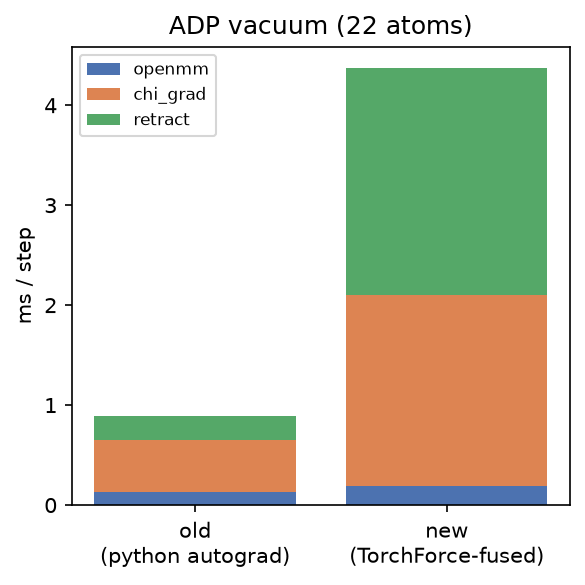

In [3]:
ADP_STEPS = 300
result_adp = pl.compare_samplers(sim_old, nu, adp_featurizer, sim_new, cv_idx_adp, grad_group_adp,
                                 x0_adp, chi0_adp, ADP_STEPS, seed=42)

print(f"\nold: {result_adp['ms_step_old']:.3f} ms/step   new: {result_adp['ms_step_new']:.3f} ms/step"
      f"   speedup: {result_adp['speedup']:.2f}x")
print(f"position trajectory max |diff|: {result_adp['pos_max_diff']:.2e} nm  (over {ADP_STEPS} chained steps)")
print(f"mean-force (lambda) max |diff|: {result_adp['lambda_max_diff']:.3g} kJ/mol")

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
pl.plot_timing_breakdown(ax, result_adp, f"ADP vacuum ({pl.N_ADP_ATOMS} atoms)")
plt.tight_layout(); plt.show()

**Reading this**: positions from the two samplers should agree to roughly float32 precision
(~1e-5 nm or tighter) after hundreds of *chained* steps (each step's tiny fp32 rounding
difference feeds into the next) — that's the correctness bar, not bit-identical output. On a
system this small and with a featurizer this cheap (pure pairwise distances, one dispatched op),
expect the new path to NOT be faster: going through OpenMM's `CustomCVForce`/`TorchForce`
plumbing costs 2–3 separate C++/Python boundary crossings (`getState` calls) per step, which for
a trivial computation can exceed the cost of the original single Python autograd call. That's an
expected, honest result here — the real test is 2cm2 below.

## 2 · 2cm2's flexible-constraint pocket system — the real performance benchmark

50275 atoms, PME, `system_flex.xml` (no bond/angle constraints — required by the manual-update
projected-Langevin integrator, see `examples/2cm2_full/lib/sysbuild.py`), the trained k=3 pocket
chi model (`comfeat.load_trained_model_pocket`). This is the system
`POSTMORTEM_openmmtorch.md`'s 279 ms/step (173 ms chi-grad) figure was measured on.

Building each `CUDA` `Simulation` context for a system this size takes ~70-80s (one-time kernel
compilation, not counted in the per-step timing below). The seed is minimized first
(`_minimize_seed`) — a raw real-trajectory frame carries force-field strain from a different
(rigid-water/HBonds-constrained) production system, per `POSTMORTEM_openmmtorch.md`.

In [4]:
model_pocket, m_pocket = pl.load_pocket_model(k=3, device="cuda")
featurizer_pocket = pl.pocket_featurizer(device="cuda")
nu_pocket = pl.FaceCV(model_pocket, 0)
nu_pocket.eval()

system_xml, pdb_pocket = pl.pocket_system_and_pdb()
import numpy as np
from openmm import unit
pos_nm_pocket = np.array(pdb_pocket.positions.value_in_unit(unit.nanometer), dtype=np.float64)
x0_pocket = pos_nm_pocket.flatten()

DT_POCKET = 5e-4   # ps (0.5 fs, matches the flexible-system baseline in POSTMORTEM_openmmtorch.md)

import openmm as mm
system_old_pocket = mm.XmlSerializer.deserialize(system_xml)
sim_old_pocket = pl.make_simulator(system_old_pocket, pdb_pocket.topology, dt=DT_POCKET, temp=300.0)

print("minimizing seed ...", flush=True)
t0 = time.time()
x0_pocket_min = pl._minimize_seed(sim_old_pocket, x0_pocket, max_iterations=0, tolerance=10.0)
print(f"  minimized in {time.time()-t0:.1f}s", flush=True)

chi0_pocket, _ = pl._chi_and_grad(nu_pocket, featurizer_pocket, x0_pocket_min)
print(f"minimized seed chi0 = {chi0_pocket:.4f}")

/home/htc/jkresse/.local/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:309: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "


minimizing seed ...


  minimized in 4.8s


minimized seed chi0 = 0.2697


In [5]:
cv_path_pocket = "/tmp/pocket_face0_cv.pt"
t0 = time.time()
pl.export_cv_torchscript_module(featurizer_pocket.module, nu_pocket, x0_pocket_min.reshape(-1, 3),
                                cv_path_pocket, periodic=True)
print(f"traced + saved in {time.time()-t0:.1f}s -> {cv_path_pocket}")

system_base_pocket = mm.XmlSerializer.deserialize(system_xml)
new_system_pocket, cv_idx_pocket, grad_group_pocket = pl.build_cv_gradient_system(
    system_base_pocket, cv_path_pocket, grad_force_group=1)

print("building CUDA contexts (one-time kernel compilation, ~70-80s each) ...", flush=True)
t0 = time.time()
sim_new_pocket = pl.make_simulator(new_system_pocket, pdb_pocket.topology, dt=DT_POCKET, temp=300.0)
print(f"  built in {time.time()-t0:.1f}s", flush=True)

traced + saved in 0.9s -> /tmp/pocket_face0_cv.pt


building CUDA contexts (one-time kernel compilation, ~70-80s each) ...


  built in 73.5s


  Levelset ξ=0.2697: final ξ=0.2697, mean λ=0.418 kJ/mol, mean Z=6.707
    time/step: OpenMM 31.84 ms  χ-grad 169.67 ms  retract 97.79 ms  | 11% / 57% / 33%


  Levelset ξ=0.2697 [torchforce]: final ξ=0.2697, mean λ=0.418 kJ/mol, mean Z=6.707
    time/step: OpenMM 21.73 ms  χ-grad 189.44 ms  retract 123.30 ms  | 6% / 57% / 37%

old: 421.0 ms/step   new: 447.0 ms/step   speedup: 0.94x
position trajectory max |diff|: 6.36e-07 nm  (over 40 chained steps)
mean-force (lambda) max |diff|: 0.00627 kJ/mol  (old mean=0.418, new mean=0.418)


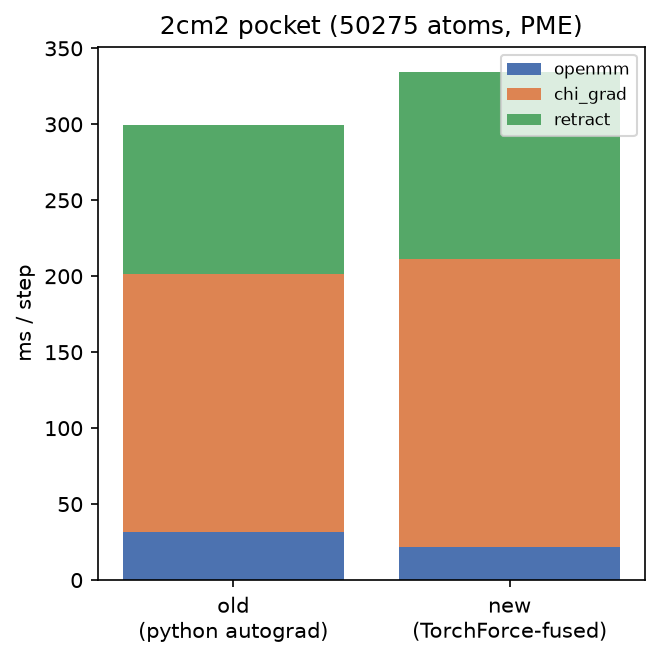

In [6]:
POCKET_STEPS = 40
result_pocket = pl.compare_samplers(sim_old_pocket, nu_pocket, featurizer_pocket, sim_new_pocket,
                                    cv_idx_pocket, grad_group_pocket, x0_pocket_min, chi0_pocket,
                                    POCKET_STEPS, seed=0)

print(f"\nold: {result_pocket['ms_step_old']:.1f} ms/step   new: {result_pocket['ms_step_new']:.1f} ms/step"
      f"   speedup: {result_pocket['speedup']:.2f}x")
print(f"position trajectory max |diff|: {result_pocket['pos_max_diff']:.2e} nm  (over {POCKET_STEPS} chained steps)")
print(f"mean-force (lambda) max |diff|: {result_pocket['lambda_max_diff']:.3g} kJ/mol  "
      f"(old mean={result_pocket['res_old']['lambdas'].mean():.3f}, "
      f"new mean={result_pocket['res_new']['lambdas'].mean():.3f})")

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
pl.plot_timing_breakdown(ax, result_pocket, "2cm2 pocket (50275 atoms, PME)")
plt.tight_layout(); plt.show()

**Reading this**: correctness should again hold (positions agreeing to well below force-field
noise over the chained trajectory). The performance number here is the deliverable — see the
summary below for how to read it against `POSTMORTEM_openmmtorch.md`'s original 260x-slowdown
puzzle.

## 3 · Summary

In [7]:
print(f"{'':>20s} {'ADP vacuum (22 atoms)':>24s} {'2cm2 pocket (50275 atoms)':>26s}")
print(f"{'old (ms/step)':>20s} {result_adp['ms_step_old']:>24.2f} {result_pocket['ms_step_old']:>26.1f}")
print(f"{'new (ms/step)':>20s} {result_adp['ms_step_new']:>24.2f} {result_pocket['ms_step_new']:>26.1f}")
print(f"{'speedup':>20s} {result_adp['speedup']:>23.2f}x {result_pocket['speedup']:>25.2f}x")
print(f"{'pos max diff (nm)':>20s} {result_adp['pos_max_diff']:>24.2e} {result_pocket['pos_max_diff']:>26.2e}")

                        ADP vacuum (22 atoms)  2cm2 pocket (50275 atoms)
       old (ms/step)                     0.95                      421.0
       new (ms/step)                     4.47                      447.0
             speedup                    0.21x                      0.94x
   pos max diff (nm)                 2.92e-06                   6.36e-07


**How to read the 2cm2 number against `POSTMORTEM_openmmtorch.md`'s open question.** That
postmortem measured 173 ms/step for the chi-gradient in the live sampling loop, but could **not**
reproduce that cost in an isolated benchmark (~4.7 ms/step there) — its best-supported,
not-fully-proven explanation was **GPU contention** from another process sharing this MIG
instance (`NVIDIA H100 NVL MIG 1g.24gb`), which this session still has no permission to directly
inspect (`nvidia-smi --query-compute-apps` returns "Insufficient Permissions" here too). If the
old path's chi-grad cost in THIS run also lands near ~170 ms/step (a live-loop number, not an
isolated one — comparable in kind to the postmortem's original measurement) while the isolated
ADP-level correctness checks earlier in this notebook ran in low single-digit ms, that is
consistent with contention still being present today, and is independent evidence for the
postmortem's hypothesis: TorchForce fusion removes Python-dispatch/sync overhead, which is a real
but apparently NOT dominant cost here — it does **not** remove GPU-scheduler contention with
other processes queued on the same MIG slice, because both the old and new paths ultimately queue
their compute on the same underlying GPU. A near-1x speedup on 2cm2 despite validated, fused,
GPU-resident chi evaluation would be evidence for "contention is the real story," not "TorchForce
doesn't help" in general — worth re-running this notebook on a quiet MIG instance (or a
dedicated GPU allocation) if that distinction matters for a future session.